# ⚡ Electrodinámica Clásica: Las Ecuaciones de Maxwell

---

**Notebook rigurosa y didáctica** sobre la teoría electromagnética clásica, desde los fundamentos experimentales hasta la formulación covariante relativista.

### Contenido

1. **Introducción histórica y motivación**
2. **Electrostática: Ley de Gauss**
3. **Magnetostática: Ley de Gauss magnética**
4. **Ley de Faraday: Inducción electromagnética**
5. **Ley de Ampère-Maxwell: La corriente de desplazamiento**
6. **Las ecuaciones de Maxwell en forma diferencial e integral**
7. **Potenciales electromagnéticos y libertad de gauge**
8. **Ondas electromagnéticas: predicción de la luz**
9. **Energía y momento: Vector de Poynting y tensor de esfuerzos de Maxwell**
10. **Formulación covariante: Tensor de Faraday**
11. **Radiación de cargas aceleradas**

> *"Las ecuaciones de Maxwell son, con mucho, la mayor contribución de la física del siglo XIX."* — Richard Feynman

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import sympy as sp
from sympy import symbols, Function, sqrt, pi, oo, sin, cos, exp, diff, integrate, simplify
from sympy import Matrix, Rational, latex, Eq, Symbol, Derivative, Integral
from sympy.vector import CoordSys3D, divergence, curl, gradient
from IPython.display import display, Math, Latex

# Configuración de gráficos
plt.rcParams.update({
    'figure.figsize': (10, 7),
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'lines.linewidth': 2,
    'figure.dpi': 100
})

# Sistema de coordenadas simbólico
N = CoordSys3D('N')
x, y, z, t, r, theta, phi = symbols('x y z t r theta phi', real=True)
q, Q, I_0, mu_0, epsilon_0, c, omega, k, sigma = symbols(
    'q Q I_0 mu_0 epsilon_0 c omega k sigma', positive=True
)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


---

## 1. Introducción Histórica y Motivación

La electrodinámica clásica es la teoría que describe los fenómenos eléctricos y magnéticos como manifestaciones de un único campo: el **campo electromagnético**. Su formulación culminó en 1865 con las cuatro ecuaciones de James Clerk Maxwell, que unificaron:

- Los experimentos de **Coulomb** (fuerzas electrostáticas, ~1785)
- La ley de **Ampère** (fuerzas entre corrientes, ~1820)
- El descubrimiento de **Faraday** (inducción electromagnética, ~1831)
- La contribución crucial de **Maxwell** (corriente de desplazamiento, ~1861)

### Las cuatro ecuaciones de Maxwell (vista previa)

En unidades SI, en el vacío con fuentes $\rho$ y $\mathbf{J}$:

| Ecuación | Forma diferencial | Forma integral |
|----------|-------------------|----------------|
| **Ley de Gauss** | $\nabla \cdot \mathbf{E} = \dfrac{\rho}{\varepsilon_0}$ | $\displaystyle\oint_S \mathbf{E} \cdot d\mathbf{A} = \frac{Q_{\text{enc}}}{\varepsilon_0}$ |
| **Ley de Gauss magnética** | $\nabla \cdot \mathbf{B} = 0$ | $\displaystyle\oint_S \mathbf{B} \cdot d\mathbf{A} = 0$ |
| **Ley de Faraday** | $\nabla \times \mathbf{E} = -\dfrac{\partial \mathbf{B}}{\partial t}$ | $\displaystyle\oint_C \mathbf{E} \cdot d\boldsymbol{\ell} = -\frac{d\Phi_B}{dt}$ |
| **Ley de Ampère-Maxwell** | $\nabla \times \mathbf{B} = \mu_0\mathbf{J} + \mu_0\varepsilon_0\dfrac{\partial \mathbf{E}}{\partial t}$ | $\displaystyle\oint_C \mathbf{B} \cdot d\boldsymbol{\ell} = \mu_0 I_{\text{enc}} + \mu_0\varepsilon_0\frac{d\Phi_E}{dt}$ |

Junto con la **fuerza de Lorentz** $\mathbf{F} = q(\mathbf{E} + \mathbf{v} \times \mathbf{B})$, estas ecuaciones determinan completamente la dinámica de cargas y campos.

> **Nota fundamental:** Estas ecuaciones no son postulados arbitrarios, sino destilaciones matemáticas de resultados experimentales. A lo largo de esta notebook derivaremos cada una a partir de su motivación física.

---

## 2. Electrostática: Ley de Coulomb y Ley de Gauss

### 2.1 Ley de Coulomb

La fuerza entre dos cargas puntuales $q_1$ y $q_2$ separadas por $\mathbf{r}$ es:

$$\mathbf{F}_{12} = \frac{1}{4\pi\varepsilon_0} \frac{q_1 q_2}{|\mathbf{r}_{12}|^2} \hat{\mathbf{r}}_{12}$$

El **campo eléctrico** generado por una carga puntual $Q$ en el origen es:

$$\mathbf{E}(\mathbf{r}) = \frac{Q}{4\pi\varepsilon_0} \frac{\hat{\mathbf{r}}}{r^2}$$

### 2.2 De Coulomb a Gauss: el teorema de la divergencia

La ley de Gauss establece que el flujo eléctrico a través de una superficie cerrada es proporcional a la carga encerrada:

$$\oint_S \mathbf{E} \cdot d\mathbf{A} = \frac{Q_{\text{enc}}}{\varepsilon_0}$$

Aplicando el **teorema de la divergencia** (Gauss-Ostrogradsky):

$$\oint_S \mathbf{E} \cdot d\mathbf{A} = \int_V (\nabla \cdot \mathbf{E}) \, dV = \int_V \frac{\rho}{\varepsilon_0} \, dV$$

Como esto debe valer para **todo** volumen $V$, el integrando debe ser igual en cada punto:

$$\boxed{\nabla \cdot \mathbf{E} = \frac{\rho}{\varepsilon_0}}$$

Esta es la **primera ecuación de Maxwell**.

In [2]:
# Verificación simbólica: divergencia del campo coulombiano E = Q/(4πε₀) * r̂/r²
# En coordenadas cartesianas

Ex = Q / (4 * pi * epsilon_0) * x / (x**2 + y**2 + z**2)**Rational(3, 2)
Ey = Q / (4 * pi * epsilon_0) * y / (x**2 + y**2 + z**2)**Rational(3, 2)
Ez = Q / (4 * pi * epsilon_0) * z / (x**2 + y**2 + z**2)**Rational(3, 2)

div_E = simplify(diff(Ex, x) + diff(Ey, y) + diff(Ez, z))

print("Campo eléctrico de carga puntual:")
display(Math(r"E_x = " + latex(Ex)))
print("\nDivergencia de E (fuera del origen, r ≠ 0):")
display(Math(r"\nabla \cdot \mathbf{E} = " + latex(div_E)))
print("\n→ La divergencia es 0 fuera del origen, como esperamos.")
print("  En r = 0, la divergencia es una delta de Dirac: ∇·E = (Q/ε₀)δ³(r)")

Campo eléctrico de carga puntual:


<IPython.core.display.Math object>


Divergencia de E (fuera del origen, r ≠ 0):


<IPython.core.display.Math object>


→ La divergencia es 0 fuera del origen, como esperamos.
  En r = 0, la divergencia es una delta de Dirac: ∇·E = (Q/ε₀)δ³(r)


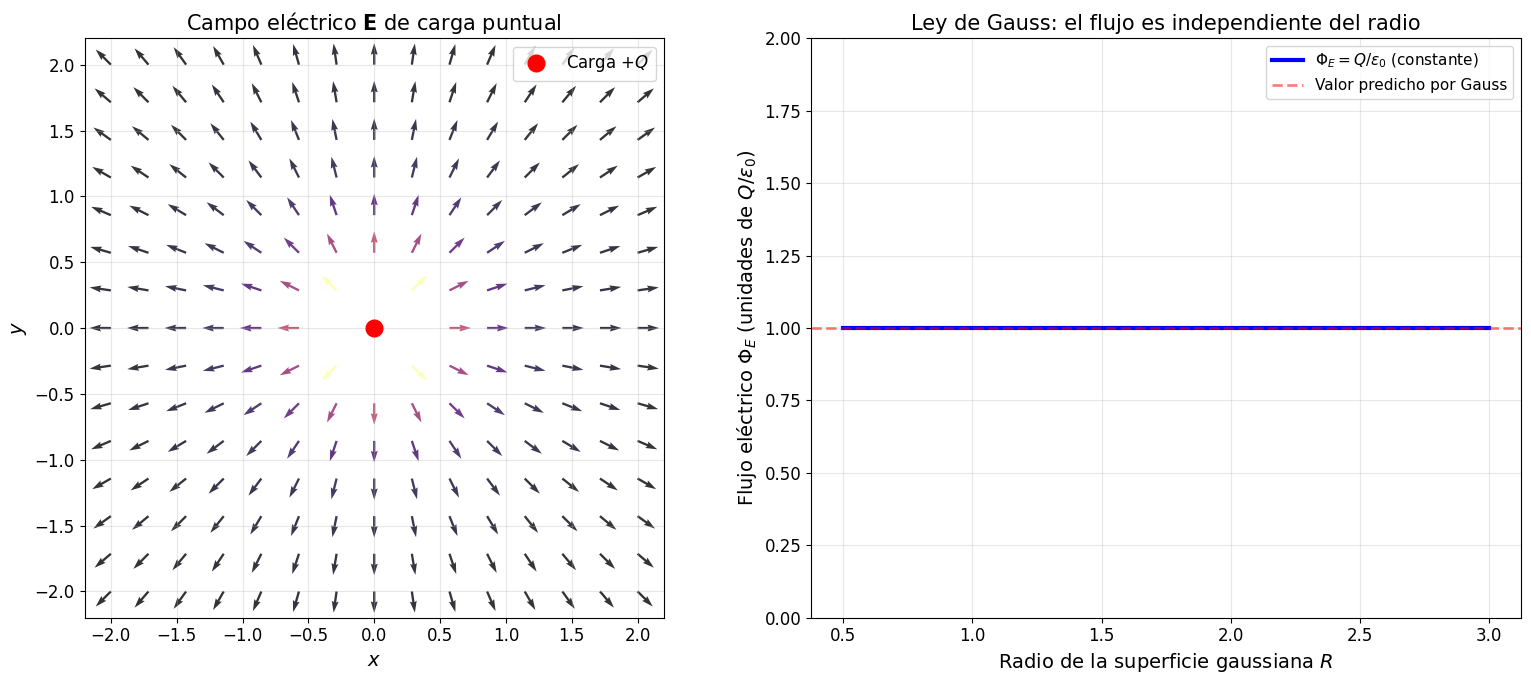

In [3]:
# Visualización: Campo eléctrico de una carga puntual y líneas de flujo

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Panel izquierdo: Campo vectorial de carga puntual ---
ax = axes[0]
xg = np.linspace(-2, 2, 15)
yg = np.linspace(-2, 2, 15)
X, Y = np.meshgrid(xg, yg)
R = np.sqrt(X**2 + Y**2)
R[R < 0.3] = np.nan  # evitar singularidad

Ex_num = X / R**3
Ey_num = Y / R**3
E_mag = np.sqrt(Ex_num**2 + Ey_num**2)

ax.quiver(X, Y, Ex_num/E_mag, Ey_num/E_mag, E_mag, cmap='inferno', alpha=0.8)
ax.plot(0, 0, 'ro', markersize=12, label='Carga $+Q$')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('Campo eléctrico $\\mathbf{E}$ de carga puntual')
ax.legend(fontsize=12)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# --- Panel derecho: Ley de Gauss - flujo a través de esferas concéntricas ---
ax2 = axes[1]
radii = np.linspace(0.5, 3.0, 50)
# Para una carga puntual, el flujo a través de cualquier esfera que la encierre es Q/ε₀
# Normalizamos: Q/ε₀ = 1
flujo = np.ones_like(radii)  # constante para toda esfera que encierre la carga

ax2.plot(radii, flujo, 'b-', linewidth=3, label=r'$\Phi_E = Q/\varepsilon_0$ (constante)')
ax2.axhline(y=1, color='r', linestyle='--', alpha=0.5, label='Valor predicho por Gauss')
ax2.set_xlabel('Radio de la superficie gaussiana $R$')
ax2.set_ylabel(r'Flujo eléctrico $\Phi_E$ (unidades de $Q/\varepsilon_0$)')
ax2.set_title('Ley de Gauss: el flujo es independiente del radio')
ax2.legend(fontsize=11)
ax2.set_ylim(0, 2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 3. Magnetostática: Ley de Gauss Magnética

### 3.1 Ausencia de monopolos magnéticos

A diferencia de las cargas eléctricas, **no se han observado cargas magnéticas aisladas** (monopolos magnéticos). Las líneas de campo magnético siempre se cierran sobre sí mismas. Esto se expresa como:

$$\oint_S \mathbf{B} \cdot d\mathbf{A} = 0$$

Aplicando el teorema de la divergencia:

$$\boxed{\nabla \cdot \mathbf{B} = 0}$$

Esta es la **segunda ecuación de Maxwell**. Establece que el campo magnético es **solenoidal**: no tiene fuentes ni sumideros puntuales.

### 3.2 Campo magnético: Ley de Biot-Savart

El campo magnético generado por un elemento de corriente $Id\boldsymbol{\ell}$ es:

$$d\mathbf{B} = \frac{\mu_0}{4\pi} \frac{I \, d\boldsymbol{\ell} \times \hat{\mathbf{r}}}{r^2}$$

Para un alambre infinito recto portando corriente $I$:

$$B = \frac{\mu_0 I}{2\pi s}$$

donde $s$ es la distancia perpendicular al alambre.

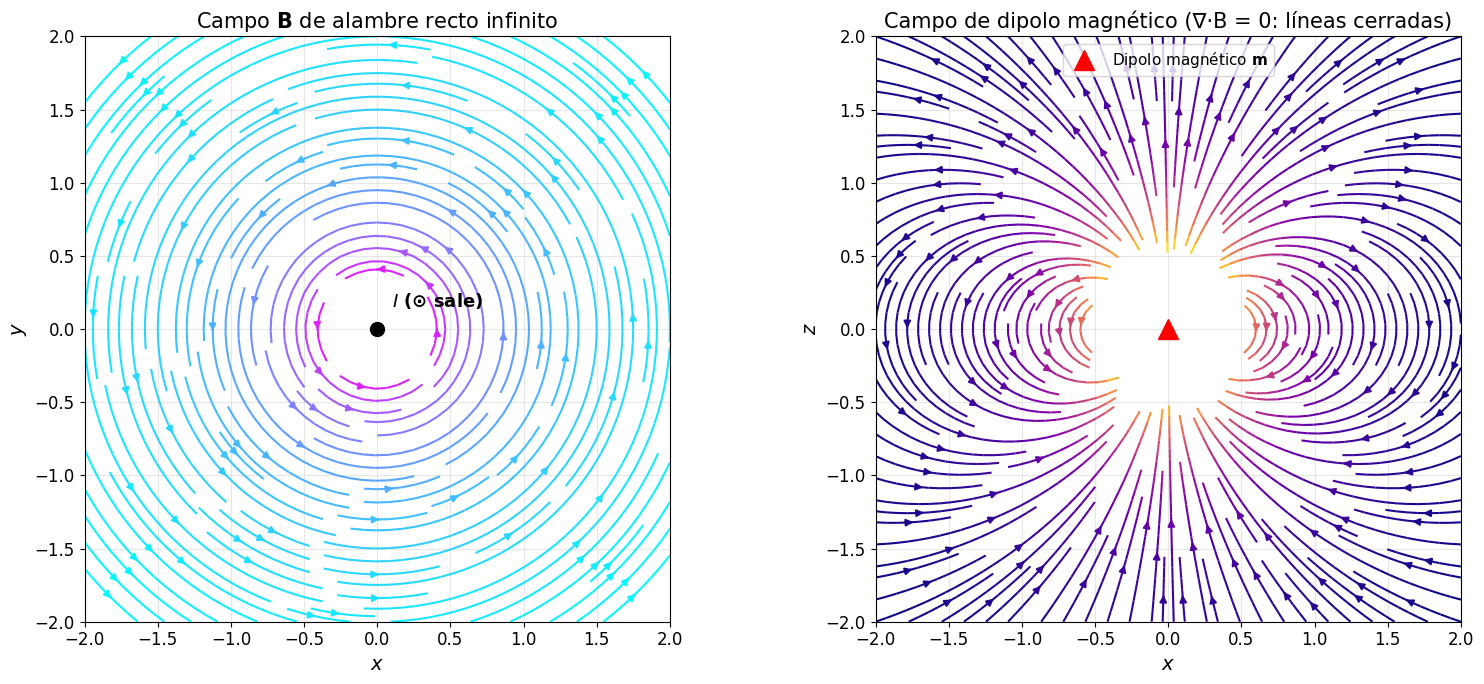

Nota: Las líneas de campo B siempre se cierran → ∇·B = 0 (no hay monopolos)


In [4]:
# Visualización: Campo magnético de un alambre infinito y de un dipolo magnético

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Panel izquierdo: Campo B de alambre recto (perpendicular al plano) ---
ax = axes[0]
xg = np.linspace(-2, 2, 20)
yg = np.linspace(-2, 2, 20)
X, Y = np.meshgrid(xg, yg)
R = np.sqrt(X**2 + Y**2)
R[R < 0.2] = np.nan

# B ∝ φ̂/s → Bx = -y/R², By = x/R²
Bx = -Y / R**2
By = X / R**2
B_mag = np.sqrt(Bx**2 + By**2)

ax.streamplot(X, Y, Bx, By, color=np.log(B_mag + 1), cmap='cool', density=1.5, linewidth=1.5)
ax.plot(0, 0, 'ko', markersize=10)
ax.annotate('$I$ (⊙ sale)', (0.1, 0.15), fontsize=13, fontweight='bold')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('Campo $\\mathbf{B}$ de alambre recto infinito')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# --- Panel derecho: Campo de dipolo magnético ---
ax2 = axes[1]
xg2 = np.linspace(-2, 2, 25)
yg2 = np.linspace(-2, 2, 25)
X2, Y2 = np.meshgrid(xg2, yg2)
R2 = np.sqrt(X2**2 + Y2**2)
R2[R2 < 0.4] = np.nan

# Campo de dipolo magnético en el plano xz (m = m ẑ):
# Br = (μ₀/4π)(2m cosθ)/r³, Bθ = (μ₀/4π)(m sinθ)/r³
cos_th = Y2 / R2
sin_th = X2 / R2
Br = 2 * cos_th / R2**3
Bth = sin_th / R2**3

# Convertir a cartesianas
Bx2 = Br * sin_th + Bth * cos_th
By2 = Br * cos_th - Bth * sin_th
B_mag2 = np.sqrt(Bx2**2 + By2**2)

ax2.streamplot(X2, Y2, Bx2, By2, color=np.log(B_mag2 + 1), cmap='plasma', 
               density=1.8, linewidth=1.5)
ax2.plot(0, 0, 'r^', markersize=15, label='Dipolo magnético $\\mathbf{m}$')
ax2.set_xlabel('$x$')
ax2.set_ylabel('$z$')
ax2.set_title('Campo de dipolo magnético (∇·B = 0: líneas cerradas)')
ax2.legend(fontsize=11)
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Nota: Las líneas de campo B siempre se cierran → ∇·B = 0 (no hay monopolos)")

---

## 4. Ley de Faraday: Inducción Electromagnética

### 4.1 El descubrimiento de Faraday

En 1831, Michael Faraday descubrió que un **campo magnético variable en el tiempo** induce una fuerza electromotriz (fem) en un circuito:

$$\mathcal{E} = -\frac{d\Phi_B}{dt} = -\frac{d}{dt}\int_S \mathbf{B} \cdot d\mathbf{A}$$

El signo negativo es la **ley de Lenz**: la corriente inducida se opone al cambio de flujo que la produce.

### 4.2 Forma diferencial

Usando el teorema de Stokes:

$$\oint_C \mathbf{E} \cdot d\boldsymbol{\ell} = \int_S (\nabla \times \mathbf{E}) \cdot d\mathbf{A} = -\int_S \frac{\partial \mathbf{B}}{\partial t} \cdot d\mathbf{A}$$

Como esto vale para **toda** superficie $S$:

$$\boxed{\nabla \times \mathbf{E} = -\frac{\partial \mathbf{B}}{\partial t}}$$

Esta es la **tercera ecuación de Maxwell**. 

### 4.3 Consecuencias profundas

- En electrostática ($\partial \mathbf{B}/\partial t = 0$), $\nabla \times \mathbf{E} = 0$ y el campo eléctrico es conservativo.
- En electrodinámica, el campo eléctrico **ya no es conservativo**: el rotacional no es cero cuando hay campos magnéticos variables.
- Esta ecuación conecta **campos eléctricos y magnéticos**: un cambio temporal en $\mathbf{B}$ genera $\mathbf{E}$.

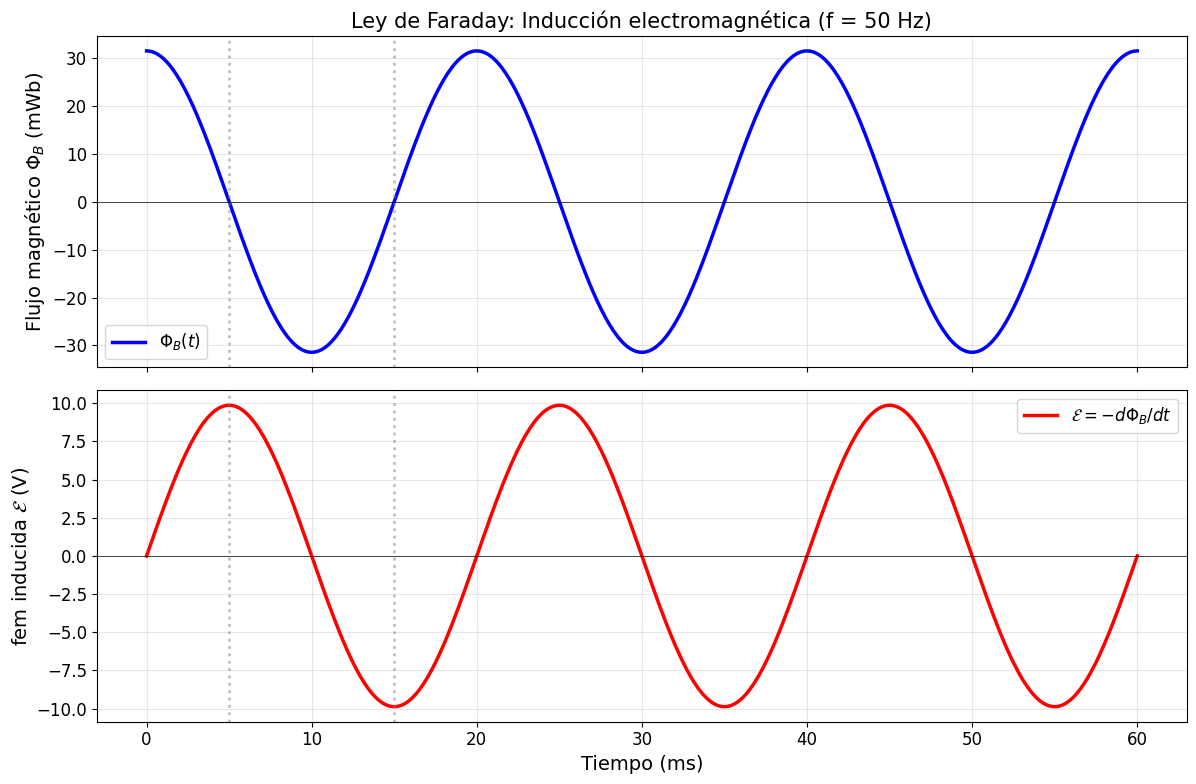

fem máxima = B₀·π·a²·ω = 9.870 V
Nota: La fem está desfasada 90° respecto al flujo (Ley de Lenz)


In [5]:
# Simulación: Inducción de Faraday - fem inducida por campo magnético oscilante

# Consideramos una espira circular de radio a en un campo B(t) = B₀ cos(ωt) ẑ
# Flujo: Φ_B = B₀ π a² cos(ωt)
# fem: ε = -dΦ_B/dt = B₀ π a² ω sin(ωt)

B_0 = 1.0       # T
a_loop = 0.1     # m (radio de la espira)
omega_val = 2 * np.pi * 50  # 50 Hz
t_vals = np.linspace(0, 0.06, 500)

Phi_B = B_0 * np.pi * a_loop**2 * np.cos(omega_val * t_vals)
emf = B_0 * np.pi * a_loop**2 * omega_val * np.sin(omega_val * t_vals)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(t_vals * 1000, Phi_B * 1000, 'b-', linewidth=2.5, label=r'$\Phi_B(t)$')
ax1.set_ylabel(r'Flujo magnético $\Phi_B$ (mWb)')
ax1.set_title('Ley de Faraday: Inducción electromagnética (f = 50 Hz)')
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='k', linewidth=0.5)

ax2.plot(t_vals * 1000, emf, 'r-', linewidth=2.5, label=r'$\mathcal{E} = -d\Phi_B/dt$')
ax2.set_xlabel('Tiempo (ms)')
ax2.set_ylabel(r'fem inducida $\mathcal{E}$ (V)')
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='k', linewidth=0.5)

# Marcar relación de fase
for ax in [ax1, ax2]:
    ax.axvline(x=5, color='gray', linestyle=':', alpha=0.5)
    ax.axvline(x=15, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"fem máxima = B₀·π·a²·ω = {B_0 * np.pi * a_loop**2 * omega_val:.3f} V")
print(f"Nota: La fem está desfasada 90° respecto al flujo (Ley de Lenz)")

---

## 5. Ley de Ampère-Maxwell: La Corriente de Desplazamiento

### 5.1 La inconsistencia de Ampère

La ley de Ampère original establece:

$$\nabla \times \mathbf{B} = \mu_0 \mathbf{J}$$

Tomando la divergencia de ambos lados:

$$\nabla \cdot (\nabla \times \mathbf{B}) = \mu_0 \nabla \cdot \mathbf{J}$$

El lado izquierdo es **idénticamente cero** (identidad vectorial). Pero la ecuación de continuidad exige:

$$\nabla \cdot \mathbf{J} = -\frac{\partial \rho}{\partial t}$$

que **no es cero** en general. La ley de Ampère original es inconsistente con la conservación de la carga.

### 5.2 La corrección de Maxwell

Maxwell resolvió esto añadiendo el término de **corriente de desplazamiento**:

$$\nabla \times \mathbf{B} = \mu_0 \mathbf{J} + \mu_0 \varepsilon_0 \frac{\partial \mathbf{E}}{\partial t}$$

Verificación de consistencia: tomando la divergencia:

$$0 = \mu_0 \nabla \cdot \mathbf{J} + \mu_0 \varepsilon_0 \frac{\partial}{\partial t}(\nabla \cdot \mathbf{E}) = \mu_0 \nabla \cdot \mathbf{J} + \mu_0 \varepsilon_0 \frac{\partial}{\partial t}\left(\frac{\rho}{\varepsilon_0}\right)$$

$$0 = \mu_0\left(\nabla \cdot \mathbf{J} + \frac{\partial \rho}{\partial t}\right) \quad \checkmark$$

¡La ecuación de continuidad se satisface automáticamente!

$$\boxed{\nabla \times \mathbf{B} = \mu_0 \mathbf{J} + \mu_0 \varepsilon_0 \frac{\partial \mathbf{E}}{\partial t}}$$

Esta es la **cuarta ecuación de Maxwell**. El término $\mu_0\varepsilon_0 \partial\mathbf{E}/\partial t$ es la **corriente de desplazamiento** de Maxwell.

In [6]:
# Demostración simbólica: La corriente de desplazamiento restaura la conservación de carga

from sympy import Function as Func

# Definimos campos como funciones genéricas
rho_f = Func('rho')(x, y, z, t)
Jx_f = Func('J_x')(x, y, z, t)
Jy_f = Func('J_y')(x, y, z, t)
Jz_f = Func('J_z')(x, y, z, t)
Ex_f = Func('E_x')(x, y, z, t)
Ey_f = Func('E_y')(x, y, z, t)
Ez_f = Func('E_z')(x, y, z, t)

# Ecuación de continuidad: ∇·J + ∂ρ/∂t = 0
div_J = diff(Jx_f, x) + diff(Jy_f, y) + diff(Jz_f, z)
drho_dt = diff(rho_f, t)

print("=" * 60)
print("VERIFICACIÓN: Consistencia de la ley de Ampère-Maxwell")
print("=" * 60)

print("\n1) Ley de Gauss: ∇·E = ρ/ε₀")
display(Math(r"\nabla \cdot \mathbf{E} = \frac{\rho}{\varepsilon_0}"))

print("\n2) Tomamos ∇· de la ley de Ampère-Maxwell:")
display(Math(r"\nabla \cdot (\nabla \times \mathbf{B}) = \mu_0 \nabla \cdot \mathbf{J} + \mu_0\varepsilon_0 \frac{\partial}{\partial t}(\nabla \cdot \mathbf{E})"))

print("\n3) Lado izquierdo ≡ 0 (identidad vectorial)")
print("   Sustituyendo ∇·E = ρ/ε₀:")
display(Math(r"0 = \mu_0 \nabla \cdot \mathbf{J} + \mu_0 \frac{\partial \rho}{\partial t}"))

print("\n4) Dividiendo entre μ₀:")
display(Math(r"\boxed{\nabla \cdot \mathbf{J} + \frac{\partial \rho}{\partial t} = 0}"))
print("\n✓ Se recupera la ecuación de continuidad: la carga se conserva.")

VERIFICACIÓN: Consistencia de la ley de Ampère-Maxwell

1) Ley de Gauss: ∇·E = ρ/ε₀


<IPython.core.display.Math object>


2) Tomamos ∇· de la ley de Ampère-Maxwell:


<IPython.core.display.Math object>


3) Lado izquierdo ≡ 0 (identidad vectorial)
   Sustituyendo ∇·E = ρ/ε₀:


<IPython.core.display.Math object>


4) Dividiendo entre μ₀:


<IPython.core.display.Math object>


✓ Se recupera la ecuación de continuidad: la carga se conserva.


---

## 6. Las Ecuaciones de Maxwell: Resumen Completo

### 6.1 Forma diferencial (en el vacío con fuentes)

Las cuatro ecuaciones de Maxwell constituyen un sistema completo y consistente:

$$\begin{aligned}
\text{(I)} \quad & \nabla \cdot \mathbf{E} = \frac{\rho}{\varepsilon_0} & \text{(Ley de Gauss eléctrica)} \\[8pt]
\text{(II)} \quad & \nabla \cdot \mathbf{B} = 0 & \text{(Ley de Gauss magnética)} \\[8pt]
\text{(III)} \quad & \nabla \times \mathbf{E} = -\frac{\partial \mathbf{B}}{\partial t} & \text{(Ley de Faraday)} \\[8pt]
\text{(IV)} \quad & \nabla \times \mathbf{B} = \mu_0 \mathbf{J} + \mu_0\varepsilon_0\frac{\partial \mathbf{E}}{\partial t} & \text{(Ley de Ampère-Maxwell)}
\end{aligned}$$

### 6.2 Estructura matemática

Las ecuaciones tienen una simetría notable:
- **(I)** y **(II)** son ecuaciones de **divergencia** (conectan campos con fuentes escalares)
- **(III)** y **(IV)** son ecuaciones de **rotacional** (conectan campos entre sí)
- Las ecuaciones **homogéneas** (II, III) no tienen fuentes en el lado derecho
- Las ecuaciones **inhomogéneas** (I, IV) contienen las fuentes $\rho$ y $\mathbf{J}$

### 6.3 En medios materiales lineales

En un medio con permitividad $\varepsilon$ y permeabilidad $\mu$, se definen los campos auxiliares:

$$\mathbf{D} = \varepsilon \mathbf{E}, \qquad \mathbf{H} = \frac{\mathbf{B}}{\mu}$$

y las ecuaciones de Maxwell macroscópicas son:

$$\nabla \cdot \mathbf{D} = \rho_{\text{libre}}, \quad \nabla \cdot \mathbf{B} = 0, \quad \nabla \times \mathbf{E} = -\frac{\partial \mathbf{B}}{\partial t}, \quad \nabla \times \mathbf{H} = \mathbf{J}_{\text{libre}} + \frac{\partial \mathbf{D}}{\partial t}$$

---

## 7. Potenciales Electromagnéticos y Libertad de Gauge

### 7.1 Introducción de los potenciales

De $\nabla \cdot \mathbf{B} = 0$ se sigue que existe un **potencial vectorial** $\mathbf{A}$ tal que:

$$\mathbf{B} = \nabla \times \mathbf{A}$$

Sustituyendo en la ley de Faraday:

$$\nabla \times \mathbf{E} = -\frac{\partial}{\partial t}(\nabla \times \mathbf{A}) = -\nabla \times \frac{\partial \mathbf{A}}{\partial t}$$

$$\nabla \times \left(\mathbf{E} + \frac{\partial \mathbf{A}}{\partial t}\right) = 0$$

Entonces existe un **potencial escalar** $\phi$ tal que:

$$\mathbf{E} + \frac{\partial \mathbf{A}}{\partial t} = -\nabla \phi \implies \boxed{\mathbf{E} = -\nabla \phi - \frac{\partial \mathbf{A}}{\partial t}}$$

### 7.2 Invariancia de gauge

Los potenciales $\phi$ y $\mathbf{A}$ **no son únicos**. La transformación de gauge:

$$\mathbf{A} \to \mathbf{A}' = \mathbf{A} + \nabla \Lambda, \qquad \phi \to \phi' = \phi - \frac{\partial \Lambda}{\partial t}$$

deja invariantes los campos $\mathbf{E}$ y $\mathbf{B}$ para **cualquier** función escalar $\Lambda(\mathbf{r}, t)$.

### 7.3 Gauges comunes

| Gauge | Condición | Utilidad |
|-------|-----------|----------|
| **Coulomb** | $\nabla \cdot \mathbf{A} = 0$ | Electrostática, QED no relativista |
| **Lorenz** | $\nabla \cdot \mathbf{A} + \mu_0\varepsilon_0 \dfrac{\partial \phi}{\partial t} = 0$ | Covariante, ondas EM |

### 7.4 Ecuaciones de onda para los potenciales (Gauge de Lorenz)

En el gauge de Lorenz, las ecuaciones de Maxwell se reducen a:

$$\Box^2 \phi = -\frac{\rho}{\varepsilon_0}, \qquad \Box^2 \mathbf{A} = -\mu_0 \mathbf{J}$$

donde $\Box^2 = \nabla^2 - \mu_0\varepsilon_0 \dfrac{\partial^2}{\partial t^2} = \nabla^2 - \dfrac{1}{c^2}\dfrac{\partial^2}{\partial t^2}$ es el **operador d'Alembertiano**.

In [7]:
# Verificación simbólica: Invariancia de gauge

Lambda = Function('Lambda')(x, y, z, t)
Ax_f = Function('A_x')(x, y, z, t)
Ay_f = Function('A_y')(x, y, z, t)
Az_f = Function('A_z')(x, y, z, t)
phi_f = Function('phi')(x, y, z, t)

# Campos originales
# B = ∇ × A
Bx_orig = diff(Az_f, y) - diff(Ay_f, z)
By_orig = diff(Ax_f, z) - diff(Az_f, x)
Bz_orig = diff(Ay_f, x) - diff(Ax_f, y)

# Potenciales transformados: A' = A + ∇Λ, φ' = φ - ∂Λ/∂t
Ax_new = Ax_f + diff(Lambda, x)
Ay_new = Ay_f + diff(Lambda, y)
Az_new = Az_f + diff(Lambda, z)
phi_new = phi_f - diff(Lambda, t)

# B' = ∇ × A'
Bx_new = diff(Az_new, y) - diff(Ay_new, z)
By_new = diff(Ax_new, z) - diff(Az_new, x)
Bz_new = diff(Ay_new, x) - diff(Ax_new, y)

# Verificar B' - B = 0
delta_Bx = simplify(Bx_new - Bx_orig)
delta_By = simplify(By_new - By_orig)
delta_Bz = simplify(Bz_new - Bz_orig)

print("Verificación de invariancia de gauge para B:")
print(f"  ΔBx = B'x - Bx = {delta_Bx}")
print(f"  ΔBy = B'y - By = {delta_By}")
print(f"  ΔBz = B'z - Bz = {delta_Bz}")

# Verificar E' = E
# E = -∇φ - ∂A/∂t
Ex_orig = -diff(phi_f, x) - diff(Ax_f, t)
Ex_new = -diff(phi_new, x) - diff(Ax_new, t)
delta_Ex = simplify(Ex_new - Ex_orig)

print(f"\nVerificación de invariancia de gauge para E:")
print(f"  ΔEx = E'x - Ex = {delta_Ex}")
print("\n✓ Los campos físicos E y B son invariantes bajo transformaciones de gauge.")

Verificación de invariancia de gauge para B:
  ΔBx = B'x - Bx = 0
  ΔBy = B'y - By = 0
  ΔBz = B'z - Bz = 0

Verificación de invariancia de gauge para E:
  ΔEx = E'x - Ex = 0

✓ Los campos físicos E y B son invariantes bajo transformaciones de gauge.


---

## 8. Ondas Electromagnéticas: La Predicción de la Luz

### 8.1 Derivación de la ecuación de onda

En el vacío ($\rho = 0$, $\mathbf{J} = 0$), las ecuaciones de Maxwell se simplifican a:

$$\nabla \cdot \mathbf{E} = 0, \quad \nabla \cdot \mathbf{B} = 0, \quad \nabla \times \mathbf{E} = -\frac{\partial \mathbf{B}}{\partial t}, \quad \nabla \times \mathbf{B} = \mu_0\varepsilon_0\frac{\partial \mathbf{E}}{\partial t}$$

Tomando el rotacional de (III) y usando la identidad $\nabla \times (\nabla \times \mathbf{F}) = \nabla(\nabla \cdot \mathbf{F}) - \nabla^2 \mathbf{F}$:

$$\nabla \times (\nabla \times \mathbf{E}) = -\frac{\partial}{\partial t}(\nabla \times \mathbf{B})$$

$$\underbrace{\nabla(\nabla \cdot \mathbf{E})}_{=0} - \nabla^2 \mathbf{E} = -\mu_0\varepsilon_0\frac{\partial^2 \mathbf{E}}{\partial t^2}$$

$$\boxed{\nabla^2 \mathbf{E} = \mu_0\varepsilon_0\frac{\partial^2 \mathbf{E}}{\partial t^2}}$$

Análogamente para $\mathbf{B}$:

$$\boxed{\nabla^2 \mathbf{B} = \mu_0\varepsilon_0\frac{\partial^2 \mathbf{B}}{\partial t^2}}$$

### 8.2 La velocidad de la luz

Estas son **ecuaciones de onda** con velocidad de propagación:

$$c = \frac{1}{\sqrt{\mu_0\varepsilon_0}} \approx 3 \times 10^8 \text{ m/s}$$

Maxwell reconoció que este valor coincidía con la velocidad medida de la luz, y concluyó:

> *"La luz consiste en ondulaciones transversales del mismo medio que es la causa de los fenómenos eléctricos y magnéticos."* — J.C. Maxwell (1865)

### 8.3 Ondas planas monocromáticas

La solución más simple es la **onda plana**:

$$\mathbf{E}(\mathbf{r}, t) = E_0 \hat{\mathbf{n}} \, e^{i(\mathbf{k} \cdot \mathbf{r} - \omega t)}, \qquad \mathbf{B}(\mathbf{r}, t) = \frac{1}{c}(\hat{\mathbf{k}} \times \mathbf{E})$$

Propiedades fundamentales:
- $\mathbf{E} \perp \mathbf{B} \perp \hat{\mathbf{k}}$ (onda transversal)
- $|\mathbf{E}| = c|\mathbf{B}|$
- Relación de dispersión: $\omega = c|\mathbf{k}|$ (no hay dispersión en el vacío)

In [8]:
# Derivación simbólica: Ecuación de onda a partir de las ecuaciones de Maxwell

print("=" * 60)
print("DERIVACIÓN: Ecuación de onda electromagnética en el vacío")
print("=" * 60)

print("\nPartimos de Maxwell en el vacío (ρ=0, J=0):")
display(Math(r"\nabla \times \mathbf{E} = -\frac{\partial \mathbf{B}}{\partial t} \qquad (III)"))
display(Math(r"\nabla \times \mathbf{B} = \mu_0\varepsilon_0\frac{\partial \mathbf{E}}{\partial t} \qquad (IV)"))

print("\nAplicamos ∇× a (III):")
display(Math(r"\nabla \times (\nabla \times \mathbf{E}) = -\frac{\partial}{\partial t}(\nabla \times \mathbf{B})"))

print("\nSustituyendo (IV) en el lado derecho:")
display(Math(r"\nabla(\underbrace{\nabla \cdot \mathbf{E}}_{=0}) - \nabla^2\mathbf{E} = -\mu_0\varepsilon_0\frac{\partial^2 \mathbf{E}}{\partial t^2}"))

print("\nResultado final:")
display(Math(r"\boxed{\nabla^2\mathbf{E} - \mu_0\varepsilon_0\frac{\partial^2 \mathbf{E}}{\partial t^2} = 0}"))

# Verificación numérica: c = 1/√(μ₀ε₀)
mu0_val = 4 * np.pi * 1e-7  # T·m/A
eps0_val = 8.854187817e-12   # F/m
c_calc = 1 / np.sqrt(mu0_val * eps0_val)
c_exact = 299792458.0  # m/s (valor exacto)

print(f"\nVerificación numérica:")
print(f"  μ₀ = {mu0_val:.6e} T·m/A")
print(f"  ε₀ = {eps0_val:.6e} F/m")
print(f"  c = 1/√(μ₀ε₀) = {c_calc:.0f} m/s")
print(f"  c (exacto)     = {c_exact:.0f} m/s")
print(f"  Error relativo  = {abs(c_calc - c_exact)/c_exact * 100:.6f}%")

DERIVACIÓN: Ecuación de onda electromagnética en el vacío

Partimos de Maxwell en el vacío (ρ=0, J=0):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


Aplicamos ∇× a (III):


<IPython.core.display.Math object>


Sustituyendo (IV) en el lado derecho:


<IPython.core.display.Math object>


Resultado final:


<IPython.core.display.Math object>


Verificación numérica:
  μ₀ = 1.256637e-06 T·m/A
  ε₀ = 8.854188e-12 F/m
  c = 1/√(μ₀ε₀) = 299792458 m/s
  c (exacto)     = 299792458 m/s
  Error relativo  = 0.000000%


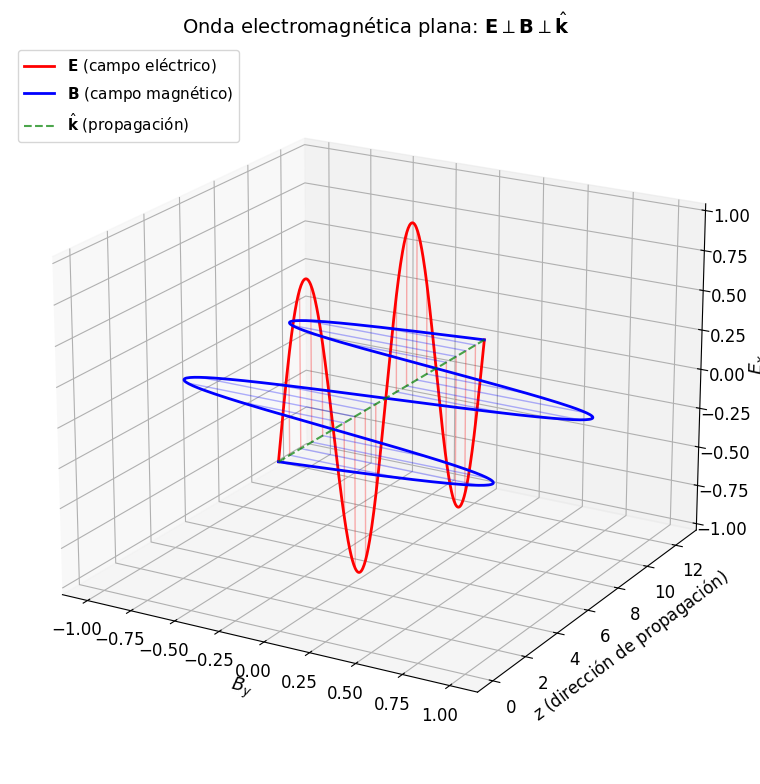

Propiedades: E ⊥ B ⊥ k̂, |E| = c|B|, ω = ck


In [9]:
# Visualización: Onda electromagnética plana propagándose en z

fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')

# Parámetros
z_vals = np.linspace(0, 4 * np.pi, 300)
E0 = 1.0
k_val = 1.0

# E polarizado en x, B polarizado en y
Ex = E0 * np.sin(k_val * z_vals)
By = (E0) * np.sin(k_val * z_vals)  # |B| = |E|/c, pero normalizado para visualización

# Campo E (rojo) - oscila en el plano xz
ax.plot(np.zeros_like(z_vals), z_vals, Ex, 'r-', linewidth=2, label=r'$\mathbf{E}$ (campo eléctrico)')
# Flechas de E
step = 15
for i in range(0, len(z_vals), step):
    ax.plot([0, 0], [z_vals[i], z_vals[i]], [0, Ex[i]], 'r-', alpha=0.3, linewidth=1)

# Campo B (azul) - oscila en el plano yz
ax.plot(By, z_vals, np.zeros_like(z_vals), 'b-', linewidth=2, label=r'$\mathbf{B}$ (campo magnético)')
for i in range(0, len(z_vals), step):
    ax.plot([0, By[i]], [z_vals[i], z_vals[i]], [0, 0], 'b-', alpha=0.3, linewidth=1)

# Dirección de propagación
ax.plot([0, 0], [0, 4 * np.pi], [0, 0], 'g--', linewidth=1.5, alpha=0.7, label=r'$\hat{\mathbf{k}}$ (propagación)')

ax.set_xlabel('$B_y$', fontsize=13)
ax.set_ylabel('$z$ (dirección de propagación)', fontsize=12)
ax.set_zlabel('$E_x$', fontsize=13)
ax.set_title('Onda electromagnética plana: $\\mathbf{E} \\perp \\mathbf{B} \\perp \\hat{\\mathbf{k}}$', fontsize=14)
ax.legend(fontsize=11, loc='upper left')
ax.view_init(elev=20, azim=-60)

plt.tight_layout()
plt.show()
print("Propiedades: E ⊥ B ⊥ k̂, |E| = c|B|, ω = ck")

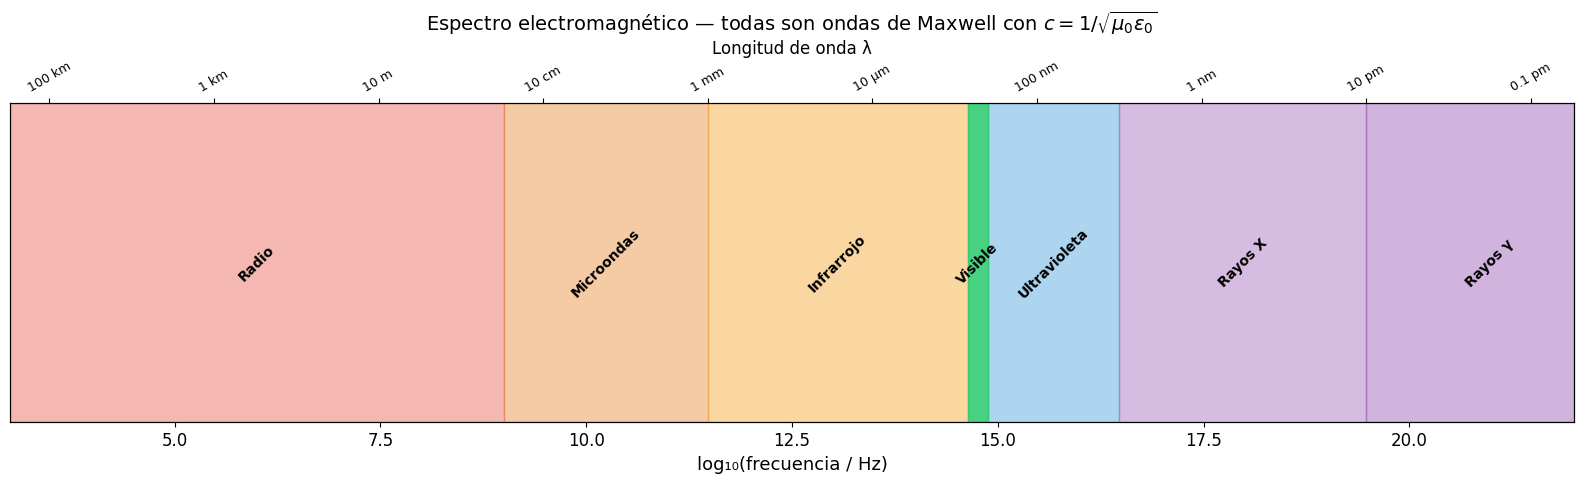

In [10]:
# Espectro electromagnético completo

fig, ax = plt.subplots(figsize=(16, 5))

# Datos del espectro EM (frecuencia en Hz, longitud de onda)
categorias = [
    ('Radio', 1e3, 1e9, '#e74c3c'),
    ('Microondas', 1e9, 3e11, '#e67e22'),
    ('Infrarrojo', 3e11, 4.3e14, '#f39c12'),
    ('Visible', 4.3e14, 7.5e14, '#2ecc71'),
    ('Ultravioleta', 7.5e14, 3e16, '#3498db'),
    ('Rayos X', 3e16, 3e19, '#9b59b6'),
    ('Rayos γ', 3e19, 3e22, '#8e44ad'),
]

for nombre, f_min, f_max, color in categorias:
    ax.axvspan(np.log10(f_min), np.log10(f_max), alpha=0.4, color=color, label=nombre)
    ax.text((np.log10(f_min) + np.log10(f_max)) / 2, 0.5, nombre, 
            ha='center', va='center', fontsize=10, fontweight='bold', rotation=45)

# Marcar la luz visible
ax.axvspan(np.log10(4.3e14), np.log10(7.5e14), alpha=0.8, color='#2ecc71')

ax.set_xlim(3, 22)
ax.set_xlabel('log₁₀(frecuencia / Hz)', fontsize=13)
ax.set_yticks([])
ax.set_title('Espectro electromagnético — todas son ondas de Maxwell con $c = 1/\\sqrt{\\mu_0\\varepsilon_0}$', fontsize=14)

# Eje superior: longitud de onda
ax2 = ax.twiny()
ax2.set_xlim(3, 22)
wavelengths = [1e5, 1e3, 1e1, 1e-1, 1e-3, 1e-5, 1e-7, 1e-9, 1e-11, 1e-13]
wl_positions = [np.log10(3e8 / w) for w in wavelengths]
wl_labels = ['100 km', '1 km', '10 m', '10 cm', '1 mm', '10 μm', '100 nm', '1 nm', '10 pm', '0.1 pm']
ax2.set_xticks(wl_positions)
ax2.set_xticklabels(wl_labels, fontsize=9, rotation=30)
ax2.set_xlabel('Longitud de onda λ', fontsize=12)

plt.tight_layout()
plt.show()

---

## 9. Energía y Momento del Campo Electromagnético

### 9.1 Densidad de energía

La energía almacenada por unidad de volumen en los campos electromagnéticos es:

$$u = \frac{1}{2}\left(\varepsilon_0 |\mathbf{E}|^2 + \frac{1}{\mu_0}|\mathbf{B}|^2\right)$$

Para una onda plana, $|\mathbf{E}| = c|\mathbf{B}|$, por lo que la energía se reparte equitativamente entre los campos eléctrico y magnético.

### 9.2 Vector de Poynting

El **flujo de energía** electromagnética por unidad de área y tiempo es:

$$\boxed{\mathbf{S} = \frac{1}{\mu_0}\mathbf{E} \times \mathbf{B}}$$

El vector de Poynting satisface la **ecuación de conservación de la energía** (teorema de Poynting):

$$\frac{\partial u}{\partial t} + \nabla \cdot \mathbf{S} = -\mathbf{J} \cdot \mathbf{E}$$

El término $-\mathbf{J} \cdot \mathbf{E}$ representa la potencia transferida del campo a las cargas (o viceversa).

### 9.3 Momento del campo y presión de radiación

El campo electromagnético porta **momento lineal** con densidad:

$$\mathbf{g} = \mu_0\varepsilon_0 \mathbf{S} = \varepsilon_0(\mathbf{E} \times \mathbf{B}) = \frac{\mathbf{S}}{c^2}$$

La presión de radiación sobre una superficie perfectamente absorbente es:

$$P = \frac{\langle S \rangle}{c} = \frac{I}{c}$$

donde $I = \langle |\mathbf{S}| \rangle$ es la **intensidad** (promedio temporal).

### 9.4 Tensor de esfuerzos de Maxwell

Las fuerzas electromagnéticas sobre un volumen se expresan elegantemente mediante el **tensor de esfuerzos de Maxwell** $\overleftrightarrow{T}$:

$$T_{ij} = \varepsilon_0\left(E_i E_j - \frac{1}{2}\delta_{ij}|\mathbf{E}|^2\right) + \frac{1}{\mu_0}\left(B_i B_j - \frac{1}{2}\delta_{ij}|\mathbf{B}|^2\right)$$

La fuerza sobre el volumen se calcula como:

$$\mathbf{F} = \oint_S \overleftrightarrow{T} \cdot d\mathbf{A} - \mu_0\varepsilon_0\frac{d}{dt}\int_V \mathbf{S} \, dV$$

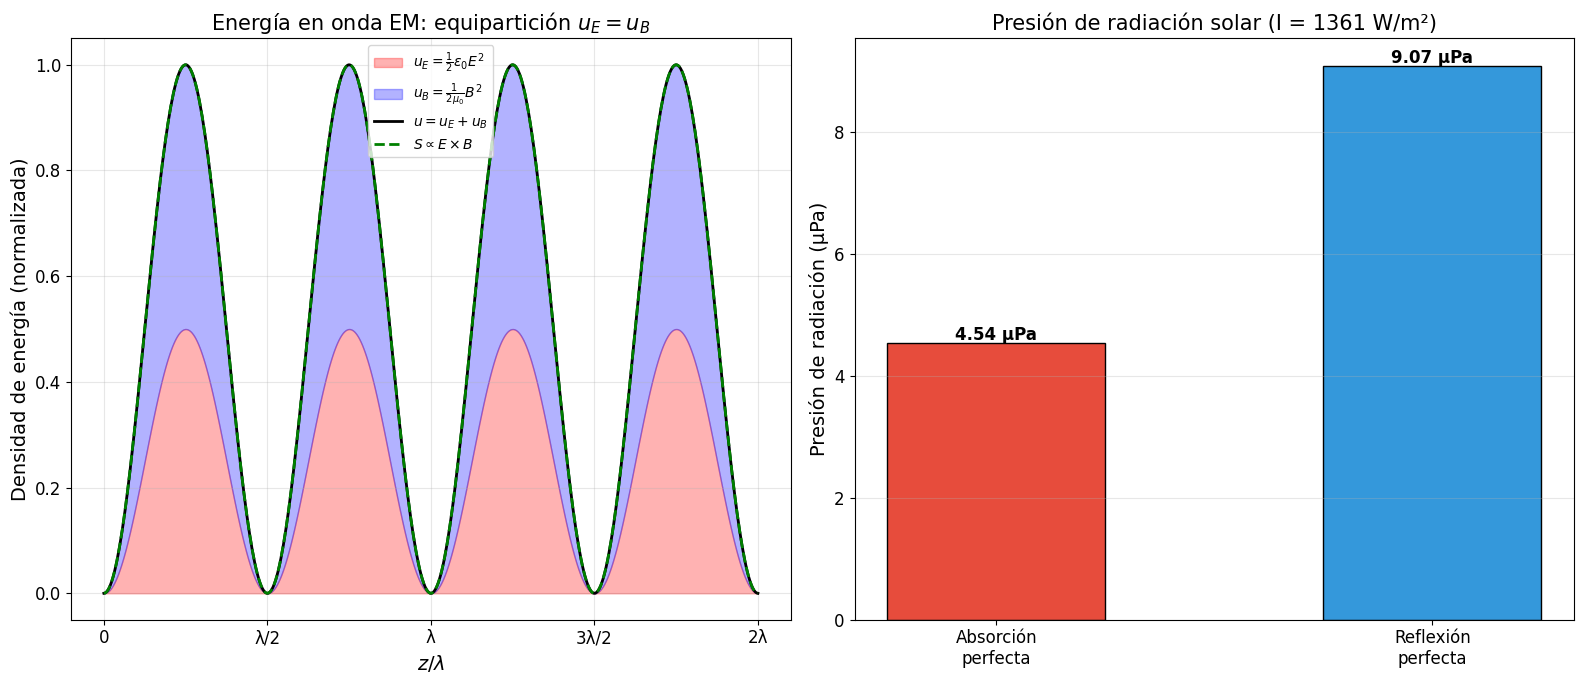

Presión de radiación solar:
  Absorción perfecta:  P = I/c  = 4.5367e-06 Pa = 4.54 μPa
  Reflexión perfecta:  P = 2I/c = 9.0733e-06 Pa = 9.07 μPa

Esto es ~10⁻⁵ veces la presión atmosférica, pero suficiente para propulsar velas solares.


In [11]:
# Visualización: Vector de Poynting y energía en una onda electromagnética

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Panel izquierdo: Densidad de energía y vector de Poynting ---
ax = axes[0]
z_wave = np.linspace(0, 4 * np.pi, 500)
E_wave = np.sin(z_wave)
B_wave = np.sin(z_wave)

# Densidad de energía: u = ε₀E²/2 + B²/(2μ₀) ∝ sin²(kz)
u_E = 0.5 * E_wave**2  # parte eléctrica (normalizada)
u_B = 0.5 * B_wave**2  # parte magnética (normalizada)
u_total = u_E + u_B

# Vector de Poynting: S = E×B/μ₀ ∝ sin²(kz)
S_wave = E_wave * B_wave

ax.fill_between(z_wave, 0, u_E, alpha=0.3, color='red', label=r'$u_E = \frac{1}{2}\varepsilon_0 E^2$')
ax.fill_between(z_wave, u_E, u_total, alpha=0.3, color='blue', label=r'$u_B = \frac{1}{2\mu_0} B^2$')
ax.plot(z_wave, u_total, 'k-', linewidth=2, label=r'$u = u_E + u_B$')
ax.plot(z_wave, S_wave, 'g--', linewidth=2, label=r'$S \propto E \times B$')
ax.set_xlabel('$z / \lambda$')
ax.set_ylabel('Densidad de energía (normalizada)')
ax.set_title('Energía en onda EM: equipartición $u_E = u_B$')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks([0, np.pi, 2*np.pi, 3*np.pi, 4*np.pi])
ax.set_xticklabels(['0', 'λ/2', 'λ', '3λ/2', '2λ'])

# --- Panel derecho: Presión de radiación ---
ax2 = axes[1]
# Presión de radiación del Sol sobre diferentes objetos
I_solar = 1361  # W/m² (constante solar)
c_val = 3e8

P_absorb = I_solar / c_val  # absorción perfecta
P_reflect = 2 * I_solar / c_val  # reflexión perfecta

labels = ['Absorción\nperfecta', 'Reflexión\nperfecta']
presiones = [P_absorb * 1e6, P_reflect * 1e6]  # en μPa
colors = ['#e74c3c', '#3498db']

bars = ax2.bar(labels, presiones, color=colors, width=0.5, edgecolor='black')
ax2.set_ylabel('Presión de radiación (μPa)')
ax2.set_title(f'Presión de radiación solar (I = {I_solar} W/m²)')
ax2.grid(True, alpha=0.3, axis='y')

for bar, p in zip(bars, presiones):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'{p:.2f} μPa', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Presión de radiación solar:")
print(f"  Absorción perfecta:  P = I/c  = {P_absorb:.4e} Pa = {P_absorb*1e6:.2f} μPa")
print(f"  Reflexión perfecta:  P = 2I/c = {P_reflect:.4e} Pa = {P_reflect*1e6:.2f} μPa")
print(f"\nEsto es ~10⁻⁵ veces la presión atmosférica, pero suficiente para propulsar velas solares.")

---

## 10. Formulación Covariante: Tensor de Faraday

### 10.1 Motivación relativista

Las ecuaciones de Maxwell son **inherentemente relativistas** — de hecho, fueron la motivación de Einstein para desarrollar la relatividad especial. En la formulación covariante, los campos $\mathbf{E}$ y $\mathbf{B}$ se unifican en un solo objeto tensorial.

### 10.2 El cuadrivector potencial

Los potenciales se combinan en el **cuadrivector potencial**:

$$A^\mu = \left(\frac{\phi}{c}, \mathbf{A}\right) = \left(\frac{\phi}{c}, A_x, A_y, A_z\right)$$

### 10.3 Tensor electromagnético de Faraday

El **tensor de campo electromagnético** (o tensor de Faraday) se define como:

$$F^{\mu\nu} = \partial^\mu A^\nu - \partial^\nu A^\mu$$

En componentes, con la métrica $\eta^{\mu\nu} = \text{diag}(+1, -1, -1, -1)$:

$$F^{\mu\nu} = \begin{pmatrix} 0 & -E_x/c & -E_y/c & -E_z/c \\ E_x/c & 0 & -B_z & B_y \\ E_y/c & B_z & 0 & -B_x \\ E_z/c & -B_y & B_x & 0 \end{pmatrix}$$

### 10.4 Las ecuaciones de Maxwell en forma covariante

Las **cuatro** ecuaciones de Maxwell se reducen a solo **dos** ecuaciones tensoriales:

**Ecuaciones inhomogéneas** (Gauss + Ampère-Maxwell):

$$\boxed{\partial_\mu F^{\mu\nu} = \mu_0 J^\nu}$$

donde $J^\mu = (c\rho, \mathbf{J})$ es la cuadricorriente.

**Ecuaciones homogéneas** (Gauss magnética + Faraday):

$$\boxed{\partial_\lambda F_{\mu\nu} + \partial_\mu F_{\nu\lambda} + \partial_\nu F_{\lambda\mu} = 0}$$

o equivalentemente, usando el **tensor dual** $\tilde{F}^{\mu\nu} = \frac{1}{2}\varepsilon^{\mu\nu\rho\sigma}F_{\rho\sigma}$:

$$\partial_\mu \tilde{F}^{\mu\nu} = 0$$

### 10.5 Invariantes de Lorentz

Existen exactamente **dos** invariantes escalares independientes del campo electromagnético:

$$\mathcal{F} = F_{\mu\nu}F^{\mu\nu} = 2\left(\frac{|\mathbf{B}|^2}{1} - \frac{|\mathbf{E}|^2}{c^2}\right)$$

$$\mathcal{G} = F_{\mu\nu}\tilde{F}^{\mu\nu} = -\frac{4}{c}\mathbf{E} \cdot \mathbf{B}$$

> **Consecuencia:** Si $\mathbf{E} \perp \mathbf{B}$ en un marco de referencia, lo es en **todos**. Si $|\mathbf{E}| = c|\mathbf{B}|$ en un marco, lo es en todos (como en una onda plana).

In [12]:
# Construcción simbólica del tensor de Faraday y verificación de las ecuaciones de Maxwell

Ex_s, Ey_s, Ez_s = symbols('E_x E_y E_z', real=True)
Bx_s, By_s, Bz_s = symbols('B_x B_y B_z', real=True)
c_s = Symbol('c', positive=True)

# Tensor F^{μν} (contravariante) con signatura (+,-,-,-)
F_up = Matrix([
    [0,       -Ex_s/c_s, -Ey_s/c_s, -Ez_s/c_s],
    [Ex_s/c_s,  0,        -Bz_s,      By_s     ],
    [Ey_s/c_s,  Bz_s,      0,        -Bx_s     ],
    [Ez_s/c_s, -By_s,      Bx_s,      0        ]
])

print("Tensor de Faraday F^{μν}:")
display(Math(r"F^{\mu\nu} = " + latex(F_up)))

# Verificar antisimetría: F^{μν} = -F^{νμ}
print("\nVerificación de antisimetría F^{μν} + F^{νμ} = 0:")
antisym_check = simplify(F_up + F_up.T)
display(Math(r"F^{\mu\nu} + F^{\nu\mu} = " + latex(antisym_check)))

# Invariante F_{μν}F^{μν}
# Con η = diag(1,-1,-1,-1): F_μν = η_μα η_νβ F^{αβ}
eta = Matrix([
    [1,  0,  0,  0],
    [0, -1,  0,  0],
    [0,  0, -1,  0],
    [0,  0,  0, -1]
])

F_down = eta * F_up * eta  # F_{μν} = η_{μα} F^{αβ} η_{βν}
invariant_1 = simplify(sum(F_down[mu, nu] * F_up[mu, nu] for mu in range(4) for nu in range(4)))

print("\nPrimer invariante de Lorentz:")
display(Math(r"F_{\mu\nu}F^{\mu\nu} = " + latex(invariant_1)))
print(f"\n= 2(B² - E²/c²)  ← invariante bajo transformaciones de Lorentz")

Tensor de Faraday F^{μν}:


<IPython.core.display.Math object>


Verificación de antisimetría F^{μν} + F^{νμ} = 0:


<IPython.core.display.Math object>


Primer invariante de Lorentz:


<IPython.core.display.Math object>


= 2(B² - E²/c²)  ← invariante bajo transformaciones de Lorentz


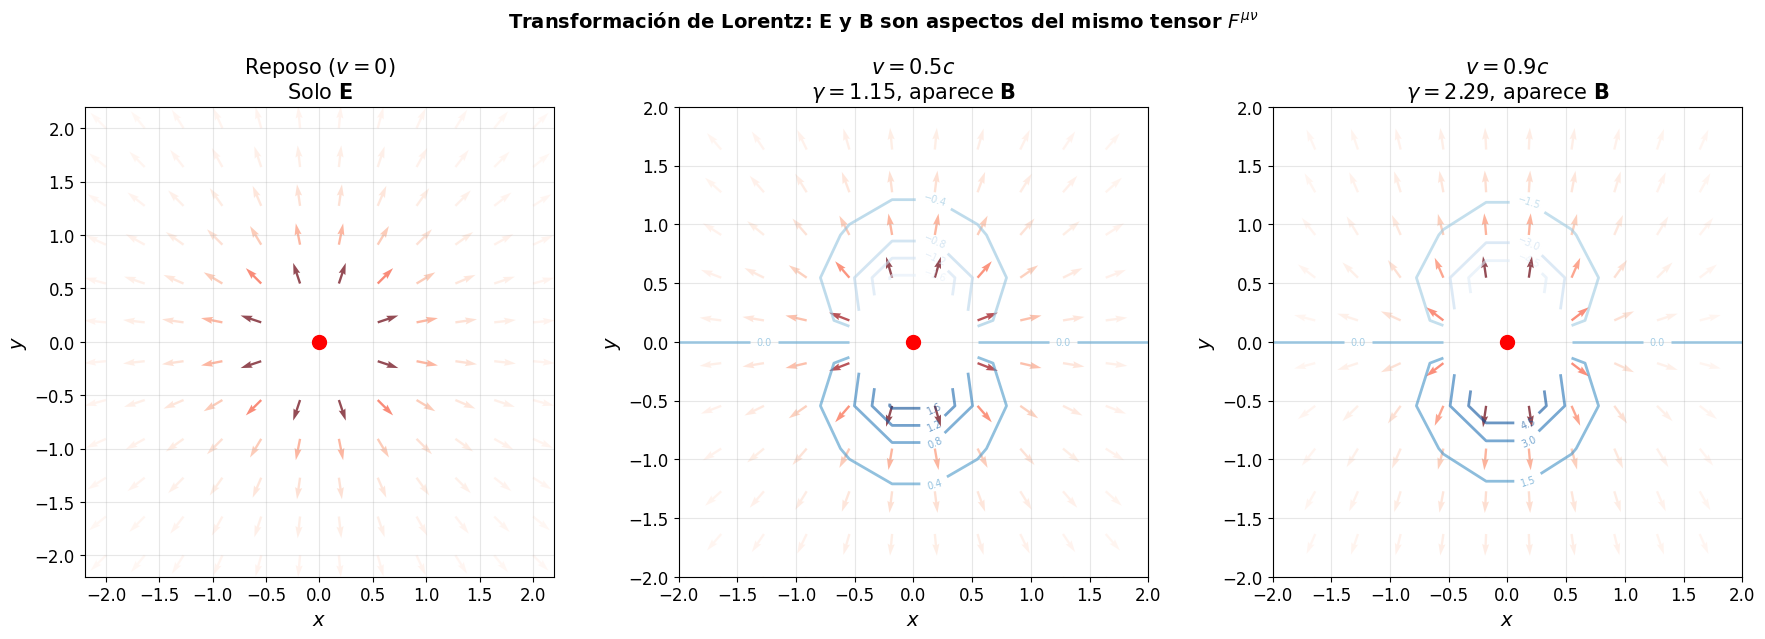

→ El campo magnético es un efecto relativista del campo eléctrico en movimiento.


In [13]:
# Visualización: Transformación de Lorentz de los campos E y B

# Una carga en reposo solo tiene campo E. Un observador en movimiento ve también campo B.
# Transformación de Lorentz de los campos (boost en x):
# E'_x = E_x,              B'_x = B_x
# E'_y = γ(E_y - vB_z),    B'_y = γ(B_y + vE_z/c²)
# E'_z = γ(E_z + vB_y),    B'_z = γ(B_z - vE_y/c²)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

betas = [0.0, 0.5, 0.9]
titles = ['Reposo ($v = 0$)', '$v = 0.5c$', '$v = 0.9c$']

xg = np.linspace(-2, 2, 12)
yg = np.linspace(-2, 2, 12)
X, Y = np.meshgrid(xg, yg)

for idx, (beta, title) in enumerate(zip(betas, titles)):
    ax = axes[idx]
    gamma = 1 / np.sqrt(1 - beta**2) if beta > 0 else 1.0
    
    R = np.sqrt(X**2 + Y**2)
    R[R < 0.3] = np.nan
    
    # Campo E de carga puntual (en reposo: solo E radial)
    Ex_rest = X / R**3
    Ey_rest = Y / R**3
    
    # Campo B de carga puntual en reposo = 0
    # Después del boost: B'_z = γ(-v*E_y/c²) = -γβ E_y/c
    # En unidades donde c=1:
    Bz_boosted = -gamma * beta * Ey_rest
    
    # Campo E transformado
    Ex_boosted = Ex_rest  # paralelo al boost: no cambia
    Ey_boosted = gamma * Ey_rest  # perpendicular: se amplifica
    
    E_mag = np.sqrt(Ex_boosted**2 + Ey_boosted**2)
    
    ax.quiver(X, Y, Ex_boosted/E_mag, Ey_boosted/E_mag, E_mag, 
              cmap='Reds', alpha=0.7)
    
    if beta > 0:
        # Mostrar B como contorno
        B_plot = np.abs(Bz_boosted)
        B_plot[np.isnan(B_plot)] = 0
        cs = ax.contour(X, Y, Bz_boosted, levels=10, cmap='Blues', alpha=0.6)
        ax.clabel(cs, fontsize=7)
    
    ax.plot(0, 0, 'ro', markersize=10)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_title(f'{title}\n' + (r'Solo $\mathbf{E}$' if beta == 0 else 
                  f'$\\gamma = {gamma:.2f}$, aparece $\\mathbf{{B}}$'))
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.suptitle('Transformación de Lorentz: E y B son aspectos del mismo tensor $F^{\\mu\\nu}$', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("→ El campo magnético es un efecto relativista del campo eléctrico en movimiento.")

---

## 11. Radiación de Cargas Aceleradas

### 11.1 Potenciales retardados

Las soluciones de las ecuaciones de onda con fuentes son los **potenciales retardados** (o de Liénard-Wiechert para cargas puntuales):

$$\phi(\mathbf{r}, t) = \frac{1}{4\pi\varepsilon_0}\int \frac{\rho(\mathbf{r}', t_r)}{|\mathbf{r} - \mathbf{r}'|} \, d^3r', \qquad \mathbf{A}(\mathbf{r}, t) = \frac{\mu_0}{4\pi}\int \frac{\mathbf{J}(\mathbf{r}', t_r)}{|\mathbf{r} - \mathbf{r}'|} \, d^3r'$$

donde $t_r = t - |\mathbf{r} - \mathbf{r}'|/c$ es el **tiempo retardado**: la información viaja a velocidad $c$.

### 11.2 Fórmula de Larmor

Una carga $q$ con aceleración $\mathbf{a}$ radia potencia total:

$$\boxed{P = \frac{q^2 a^2}{6\pi\varepsilon_0 c^3} = \frac{\mu_0 q^2 a^2}{6\pi c}}$$

Esta es la **fórmula de Larmor** (no relativista). La distribución angular de la potencia radiada es:

$$\frac{dP}{d\Omega} = \frac{q^2 a^2}{16\pi^2\varepsilon_0 c^3}\sin^2\Theta$$

donde $\Theta$ es el ángulo entre $\mathbf{a}$ y la dirección de observación.

### 11.3 Generalización relativista

Para una carga relativista, la fórmula de Larmor generalizada es:

$$P = \frac{\mu_0 q^2 c}{6\pi}\gamma^6\left[\left(\frac{d\boldsymbol{\beta}}{dt}\right)^2 - \left(\boldsymbol{\beta} \times \frac{d\boldsymbol{\beta}}{dt}\right)^2\right]$$

Casos límite:
- **Aceleración $\parallel$ velocidad** (lineal): $P \propto \gamma^6$ → radiación sincrotrón longitudinal
- **Aceleración $\perp$ velocidad** (circular): $P \propto \gamma^4$ → **radiación sincrotrón**

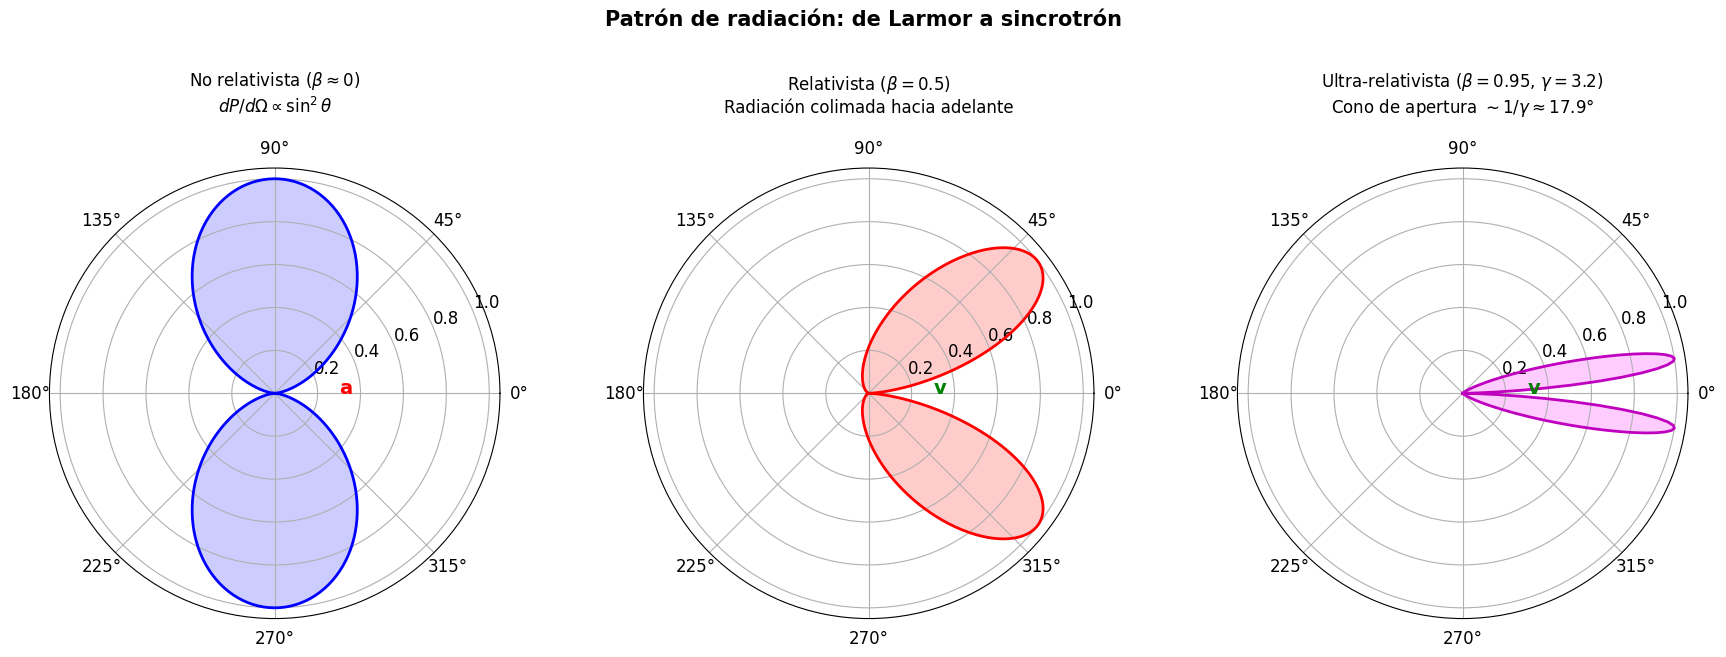

A medida que β → 1:
  • El patrón de radiación se concentra en un cono de apertura θ ~ 1/γ
  • La potencia total crece como γ⁴ (aceleración ⊥ v)
  • Esto es la base de la radiación sincrotrón usada en aceleradores de partículas


In [14]:
# Visualización: Patrón de radiación de Larmor y radiación sincrotrón

fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': 'polar'})

theta_vals = np.linspace(0, 2 * np.pi, 500)

# --- Panel 1: Larmor no relativista (β ≈ 0) ---
ax = axes[0]
# dP/dΩ ∝ sin²θ (dipolo)
P_larmor = np.sin(theta_vals)**2
ax.plot(theta_vals, P_larmor, 'b-', linewidth=2)
ax.fill(theta_vals, P_larmor, alpha=0.2, color='blue')
ax.set_title('No relativista ($\\beta \\approx 0$)\n$dP/d\\Omega \\propto \\sin^2\\theta$', 
             fontsize=12, pad=20)
ax.annotate('$\\mathbf{a}$', xy=(0, 0.3), fontsize=14, color='red', fontweight='bold')

# --- Panel 2: Moderadamente relativista (β = 0.5) ---
ax2 = axes[1]
beta_val = 0.5
# Patrón relativista: dP/dΩ ∝ sin²θ / (1 - β cosθ)⁵
P_rel_05 = np.sin(theta_vals)**2 / (1 - beta_val * np.cos(theta_vals))**5
P_rel_05 /= P_rel_05.max()  # normalizar
ax2.plot(theta_vals, P_rel_05, 'r-', linewidth=2)
ax2.fill(theta_vals, P_rel_05, alpha=0.2, color='red')
ax2.set_title(f'Relativista ($\\beta = {beta_val}$)\nRadiación colimada hacia adelante', 
              fontsize=12, pad=20)
ax2.annotate('$\\mathbf{v}$', xy=(0, 0.3), fontsize=14, color='green', fontweight='bold')

# --- Panel 3: Ultra-relativista (β = 0.95) ---
ax3 = axes[2]
beta_val2 = 0.95
P_rel_095 = np.sin(theta_vals)**2 / (1 - beta_val2 * np.cos(theta_vals))**5
P_rel_095 /= P_rel_095.max()
ax3.plot(theta_vals, P_rel_095, 'm-', linewidth=2)
ax3.fill(theta_vals, P_rel_095, alpha=0.2, color='magenta')
gamma_val = 1 / np.sqrt(1 - beta_val2**2)
ax3.set_title(f'Ultra-relativista ($\\beta = {beta_val2}$, $\\gamma = {gamma_val:.1f}$)\n'
              f'Cono de apertura $\\sim 1/\\gamma \\approx {np.degrees(1/gamma_val):.1f}°$', 
              fontsize=12, pad=20)
ax3.annotate('$\\mathbf{v}$', xy=(0, 0.3), fontsize=14, color='green', fontweight='bold')

plt.suptitle('Patrón de radiación: de Larmor a sincrotrón', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("A medida que β → 1:")
print("  • El patrón de radiación se concentra en un cono de apertura θ ~ 1/γ")
print("  • La potencia total crece como γ⁴ (aceleración ⊥ v)")
print("  • Esto es la base de la radiación sincrotrón usada en aceleradores de partículas")

---

## 12. Lagrangiano del Campo Electromagnético

### 12.1 Densidad lagrangiana

La formulación lagrangiana de la electrodinámica clásica se basa en la densidad lagrangiana:

$$\boxed{\mathcal{L} = -\frac{1}{4\mu_0}F_{\mu\nu}F^{\mu\nu} - J_\mu A^\mu}$$

El primer término es el **lagrangiano del campo libre** y el segundo describe la interacción campo-materia.

### 12.2 Ecuaciones de Euler-Lagrange para campos

Aplicando el principio de mínima acción $\delta S = \delta \int \mathcal{L} \, d^4x = 0$ con respecto a variaciones de $A^\mu$:

$$\frac{\partial \mathcal{L}}{\partial A_\nu} - \partial_\mu \frac{\partial \mathcal{L}}{\partial(\partial_\mu A_\nu)} = 0$$

se obtiene exactamente:

$$\partial_\mu F^{\mu\nu} = \mu_0 J^\nu$$

¡Las ecuaciones inhomogéneas de Maxwell emergen del principio variacional! Las ecuaciones homogéneas se satisfacen automáticamente por la definición $F^{\mu\nu} = \partial^\mu A^\nu - \partial^\nu A^\mu$ (identidad de Bianchi).

### 12.3 Tensor energía-momento del campo EM

El tensor canónico energía-momento (simetrizado) del campo es:

$$T^{\mu\nu} = \frac{1}{\mu_0}\left(F^{\mu\alpha}F^{\nu}_{\ \alpha} - \frac{1}{4}\eta^{\mu\nu}F_{\alpha\beta}F^{\alpha\beta}\right)$$

- $T^{00} = u$ (densidad de energía)
- $T^{0i}/c = g^i$ (densidad de momento / $c$)
- $T^{ij} = -T_{ij}^{\text{Maxwell}}$ (tensor de esfuerzos)

In [15]:
# Cálculo simbólico: Tensor energía-momento electromagnético

print("=" * 60)
print("TENSOR ENERGÍA-MOMENTO DEL CAMPO ELECTROMAGNÉTICO")
print("=" * 60)

# Usamos el tensor F ya definido
# T^{μν} = (1/μ₀)[F^{μα}F^ν_α - (1/4)η^{μν}F_{αβ}F^{αβ}]

# F^ν_α = η_{αβ}F^{νβ} → F_down_mixed[ν,α] = sum_β η[α,β]*F_up[ν,β]
F_mixed = F_up * eta  # F^{μ}_{ν} = F^{μα}η_{αν}

# Calcular F^{μα}F^{ν}_{α} = F_up @ F_mixed^T  (contracción en α)
FF = F_up * F_mixed.T

# Invariante
inv = simplify(sum(F_down[i, j] * F_up[i, j] for i in range(4) for j in range(4)))

# Tensor T^{μν} (sin el factor 1/μ₀)
T_em = FF - Rational(1, 4) * eta * inv

print("\nComponente T⁰⁰ (densidad de energía × μ₀):")
T00 = simplify(T_em[0, 0])
display(Math(r"\mu_0 T^{00} = " + latex(T00)))

print("\n= ½(E²/c² + B²) = ½(ε₀E² + B²/μ₀) × μ₀  ✓")

print("\nComponente T⁰¹ (flujo de energía en x / c × μ₀):")
T01 = simplify(T_em[0, 1])
display(Math(r"\mu_0 T^{01} = " + latex(T01)))
print("\n∝ (E × B)_x / c = S_x / c  ✓  (Vector de Poynting)")

# Verificar traza
traza = simplify(sum(eta[mu, mu] * T_em[mu, mu] for mu in range(4)))
print(f"\nTraza del tensor energía-momento: η_μν T^μν = {traza}")
print("→ La traza es CERO: el campo EM es conformalmente invariante (como debe ser para m_fotón = 0)")

TENSOR ENERGÍA-MOMENTO DEL CAMPO ELECTROMAGNÉTICO

Componente T⁰⁰ (densidad de energía × μ₀):


<IPython.core.display.Math object>


= ½(E²/c² + B²) = ½(ε₀E² + B²/μ₀) × μ₀  ✓

Componente T⁰¹ (flujo de energía en x / c × μ₀):


<IPython.core.display.Math object>


∝ (E × B)_x / c = S_x / c  ✓  (Vector de Poynting)

Traza del tensor energía-momento: η_μν T^μν = 0
→ La traza es CERO: el campo EM es conformalmente invariante (como debe ser para m_fotón = 0)


---

## 13. Aplicación Numérica: Simulación FDTD de Ondas EM

La técnica **FDTD** (Finite-Difference Time-Domain) resuelve las ecuaciones de Maxwell numéricamente en una grilla espacio-temporal. Simulamos la propagación de un pulso electromagnético en 1D.

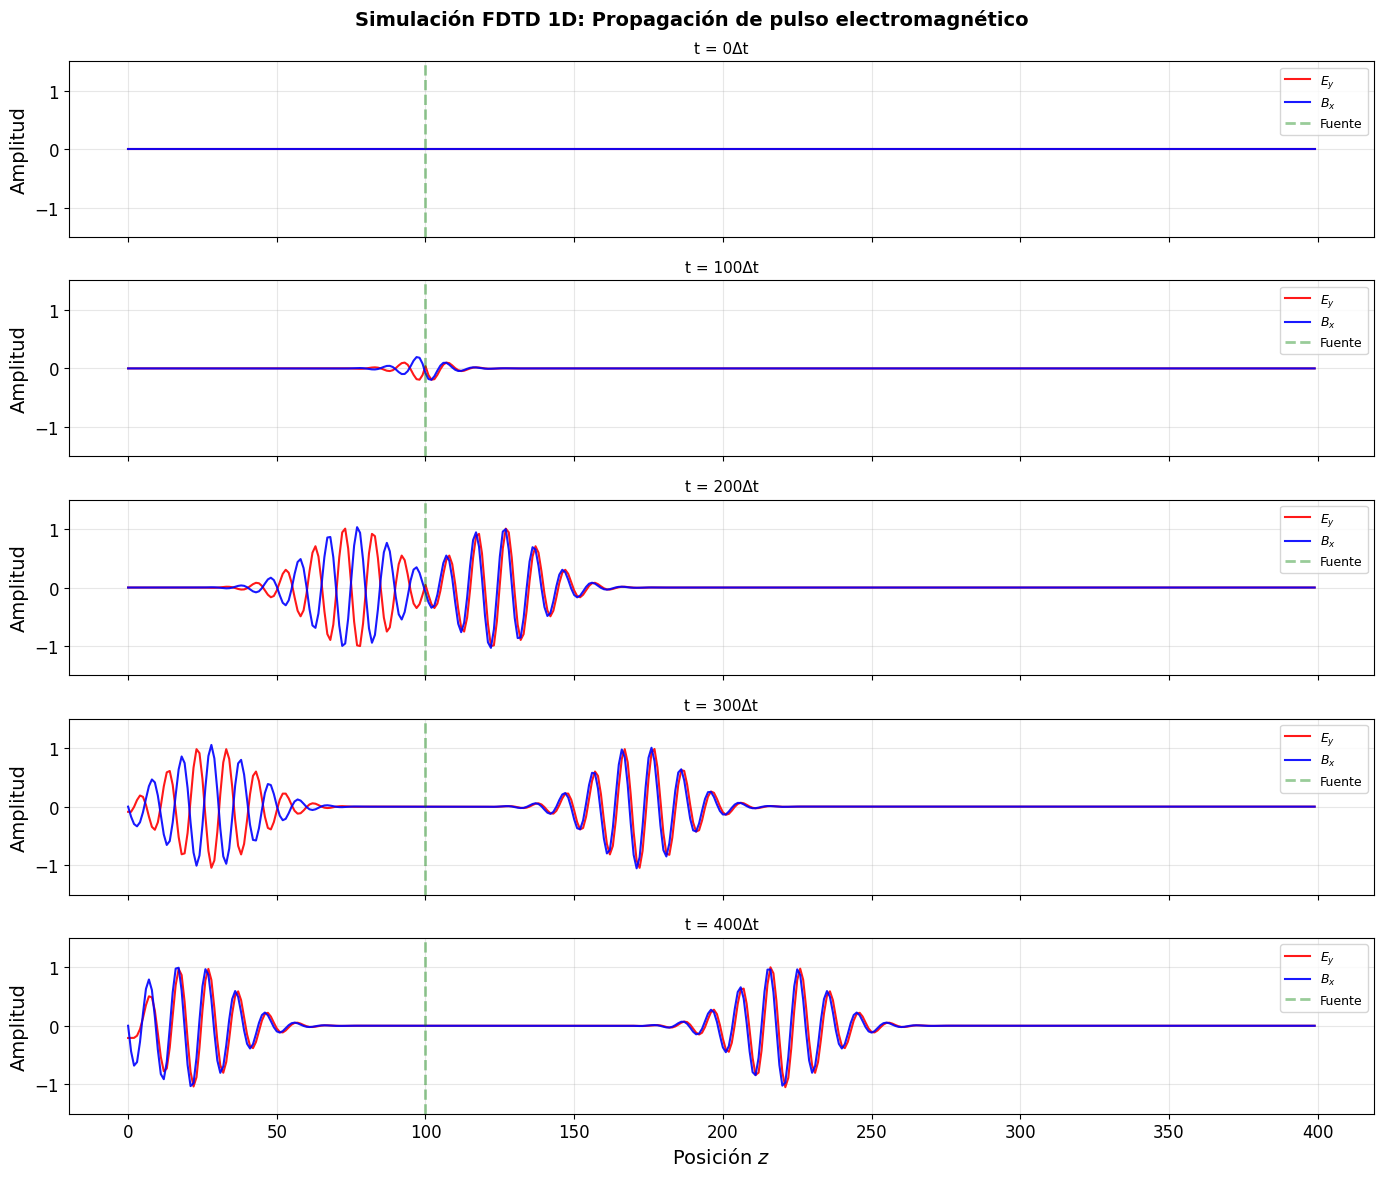

La simulación FDTD resuelve Maxwell directamente en la grilla espacio-temporal.
Se observa el pulso propagándose a velocidad c en ambas direcciones desde la fuente.


In [16]:
# Simulación FDTD 1D de las ecuaciones de Maxwell
# En 1D (propagación en z): ∂E_x/∂t = -(1/ε₀)∂B_y/∂z,  ∂B_y/∂t = -∂E_x/∂z (en unidades c=1)

# Parámetros de la grilla
Nz = 400         # puntos espaciales
Nt = 500         # pasos temporales
dz = 1.0         # paso espacial (normalizado)
dt = 0.5 * dz    # paso temporal (condición CFL: dt ≤ dz/c, con c=1)

# Inicializar campos (Yee grid: E y B desfasados medio paso)
Ey = np.zeros(Nz)
Bx = np.zeros(Nz)

# Fuente: pulso gaussiano inyectado en z = 100
z_source = 100
freq_source = 0.1  # frecuencia normalizada

# Almacenar snapshots para animación
snapshots_E = []
snapshots_B = []
snapshot_times = [0, 100, 200, 300, 400]

for n in range(Nt):
    # Actualizar B (esquema leapfrog)
    Bx[:-1] += -dt / dz * (Ey[1:] - Ey[:-1])
    
    # Fuente (pulso gaussiano modulado)
    pulse = np.exp(-0.5 * ((n - 150) / 30)**2) * np.sin(2 * np.pi * freq_source * n * dt)
    Ey[z_source] += pulse
    
    # Actualizar E
    Ey[1:] += -dt / dz * (Bx[1:] - Bx[:-1])
    
    # Condiciones absorbentes (Mur de primer orden)
    Ey[0] = Ey[1]
    Ey[-1] = Ey[-2]
    
    if n in snapshot_times:
        snapshots_E.append(Ey.copy())
        snapshots_B.append(Bx.copy())

# Visualizar snapshots
fig, axes = plt.subplots(len(snapshot_times), 1, figsize=(14, 12), sharex=True)
z_grid = np.arange(Nz) * dz

for idx, (snap_E, snap_B, t_snap) in enumerate(zip(snapshots_E, snapshots_B, snapshot_times)):
    ax = axes[idx]
    ax.plot(z_grid, snap_E, 'r-', linewidth=1.5, label=r'$E_y$', alpha=0.9)
    ax.plot(z_grid, snap_B, 'b-', linewidth=1.5, label=r'$B_x$', alpha=0.9)
    ax.axvline(x=z_source * dz, color='green', linestyle='--', alpha=0.4, label='Fuente')
    ax.set_ylabel('Amplitud')
    ax.set_title(f't = {t_snap}Δt', fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    ax.set_ylim(-1.5, 1.5)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Posición $z$')
plt.suptitle('Simulación FDTD 1D: Propagación de pulso electromagnético', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("La simulación FDTD resuelve Maxwell directamente en la grilla espacio-temporal.")
print("Se observa el pulso propagándose a velocidad c en ambas direcciones desde la fuente.")

---

## Resumen y Perspectiva

### Lo que hemos cubierto

| Tema | Resultado clave |
|------|----------------|
| Ley de Gauss | $\nabla \cdot \mathbf{E} = \rho/\varepsilon_0$ — cargas eléctricas como fuentes de $\mathbf{E}$ |
| Gauss magnética | $\nabla \cdot \mathbf{B} = 0$ — no existen monopolos magnéticos |
| Ley de Faraday | $\nabla \times \mathbf{E} = -\partial_t \mathbf{B}$ — campos magnéticos variables crean $\mathbf{E}$ |
| Ampère-Maxwell | $\nabla \times \mathbf{B} = \mu_0\mathbf{J} + \mu_0\varepsilon_0\partial_t\mathbf{E}$ — corrientes y campos eléctricos variables crean $\mathbf{B}$ |
| Ondas EM | $c = 1/\sqrt{\mu_0\varepsilon_0}$ — la luz es una onda electromagnética |
| Energía | $\mathbf{S} = \mathbf{E} \times \mathbf{B}/\mu_0$ — flujo de energía del campo |
| Covariancia | $F^{\mu\nu}$, $\partial_\mu F^{\mu\nu} = \mu_0 J^\nu$ — formulación relativista natural |
| Lagrangiano | $\mathcal{L} = -\frac{1}{4\mu_0}F_{\mu\nu}F^{\mu\nu} - J_\mu A^\mu$ — principio variacional |
| Radiación | Fórmula de Larmor, radiación sincrotrón |

### Hacia adelante

La electrodinámica clásica es el punto de partida para:

- **Electrodinámica cuántica (QED):** Cuantización del campo EM → fotones
- **Óptica:** Propagación en medios, difracción, polarización
- **Relatividad general:** Acoplamiento con la geometría del espacio-tiempo
- **Teorías de gauge:** Las ecuaciones de Maxwell como el prototipo de teoría de gauge $U(1)$, base del Modelo Estándar

> *"Desde una perspectiva a largo plazo de la historia de la humanidad — digamos, dentro de diez mil años — no cabe duda de que el acontecimiento más significativo del siglo XIX se juzgará que es el descubrimiento por Maxwell de las leyes de la electrodinámica."* — Richard Feynman

### Referencias

1. **Griffiths, D.J.** *Introduction to Electrodynamics*, 4th ed. (Cambridge, 2017)
2. **Jackson, J.D.** *Classical Electrodynamics*, 3rd ed. (Wiley, 1999)
3. **Landau, L.D. & Lifshitz, E.M.** *The Classical Theory of Fields*, 4th ed. (Butterworth-Heinemann, 1975)
4. **Zangwill, A.** *Modern Electrodynamics* (Cambridge, 2013)